<a href="https://colab.research.google.com/github/rfaoktvian/Dicoding_FinalProject/blob/main/FractureNet_High_Sensitivity_X_Ray_Image_Classification_for_Orthopedic_Diagnostics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUSINESS UNDERSTANDING


### ABOUT PROJECT

Diagnosis patah tulang (bone fracture) melalui citra X-ray adalah salah satu tugas paling umum namun krusial dalam radiologi. Di unit gawat darurat (UGD) yang sibuk, beban kerja radiolog yang tinggi dapat menyebabkan kelelahan, yang berisiko pada missed diagnosis—terutama pada kasus retakan rambut (hairline fractures) yang sangat tipis dan samar.

Proyek ini bertujuan untuk membangun sistem pendukung keputusan klinis (Clinical Decision Support System) berbasis Deep Learning yang mampu melakukan Skrining Otomatis: Mendeteksi keberadaan patah tulang pada berbagai wilayah tubuh (Multi-Region) secara instan.

Dataset:
Dataset yang digunakan adalah Fracture Multi-Region X-ray Steps yang mencakup berbagai anatomi tubuh (seperti tangan, kaki, panggul, dll). Berikut sumber dari dataset yang digunakan:
https://www.kaggle.com/datasets/bmadushanirodrigo/fracture-multi-region-x-ray-data .


### IMPORT LIBRARY

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers,models,callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import os

### LOAD DATASET

In [3]:
from google.colab import drive
drive.mount('/content/drive')

base_dir = '/content/drive/MyDrive/Dicoding/FinalProject/ProyeksiGambar/Bone_Fracture_Binary_Classification/Bone_Fracture_Binary_Classification'
TRAIN_PATH = os.path.join(base_dir,'train')
VAL_PATH = os.path.join(base_dir,'val')
TEST_PATH = os.path.join(base_dir,'test')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## EXPLORATORY DATA ANALYSIS

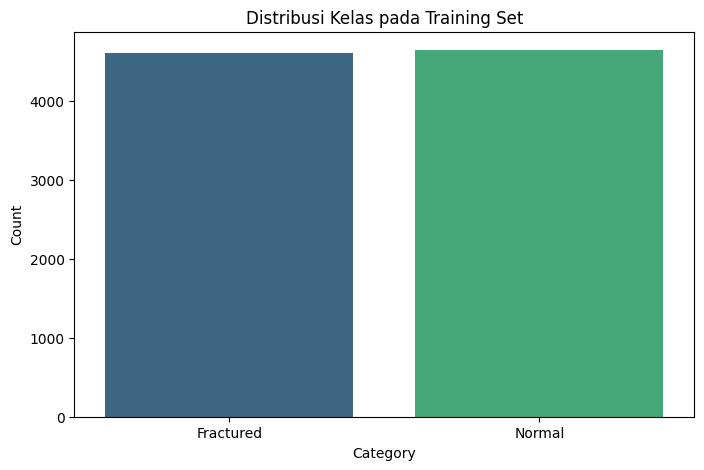

Total Fractured: 4606
Total Normal: 4640


In [4]:
train_fractured = len(os.listdir(os.path.join(TRAIN_PATH, 'fractured')))
train_normal = len(os.listdir(os.path.join(TRAIN_PATH, 'not fractured')))

data = {'Category': ['Fractured', 'Normal'], 'Count': [train_fractured, train_normal]}
df = pd.DataFrame(data)

plt.figure(figsize=(8, 5))
sns.barplot(x='Category', y='Count', hue='Category', data=df, palette='viridis',legend=False)
plt.title('Distribusi Kelas pada Training Set')
plt.show()

print(f"Total Fractured: {train_fractured}")
print(f"Total Normal: {train_normal}")

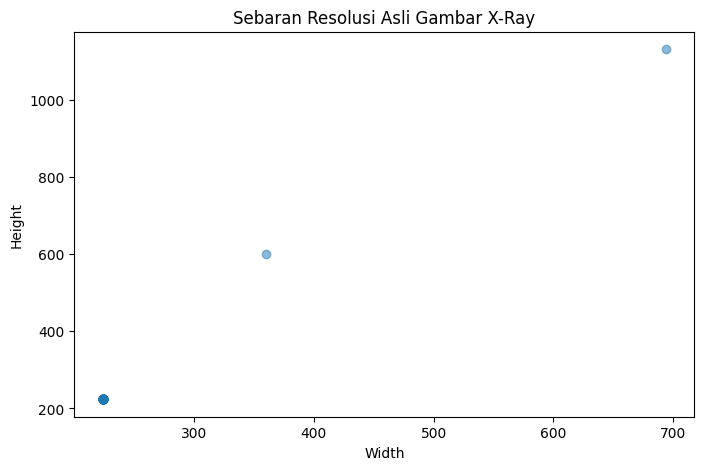

In [10]:
from PIL import Image,ImageFile

sample_dir = os.path.join(TRAIN_PATH, 'fractured')
sample_files = os.listdir(sample_dir)[:50]

widths = []
heights = []

for file in sample_files:
    img = Image.open(os.path.join(sample_dir, file))
    widths.append(img.size[0])
    heights.append(img.size[1])

plt.figure(figsize=(8, 5))
plt.scatter(widths, heights, alpha=0.5)
plt.xlabel('Width')
plt.ylabel('Height')
plt.title('Sebaran Resolusi Asli Gambar X-Ray')
plt.show()

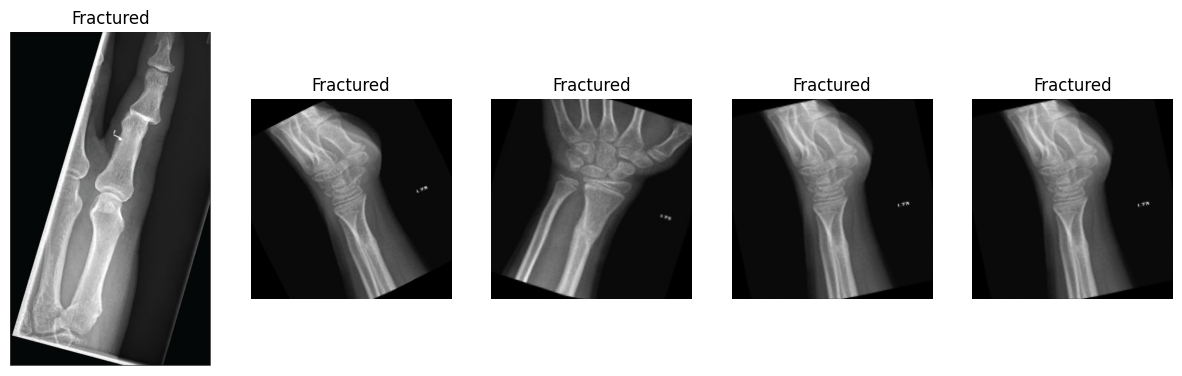

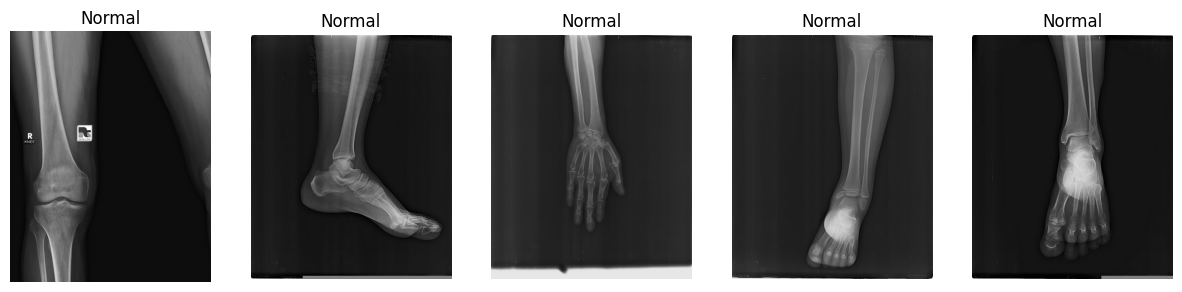

In [11]:
ImageFile.LOAD_TRUNCATED_IMAGES = True
def plot_raw_samples(path, title):
    files = os.listdir(path)[:5]
    plt.figure(figsize=(15, 5))
    for i, file in enumerate(files):
        img = Image.open(os.path.join(path, file))
        plt.subplot(1, 5, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(title)
        plt.axis('off')
    plt.show()
plot_raw_samples(os.path.join(TRAIN_PATH, 'fractured'), "Fractured")
plot_raw_samples(os.path.join(TRAIN_PATH, 'not fractured'), "Normal")